In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
from sklearn.metrics import roc_auc_score, average_precision_score
import torch
import torchmetrics

In [2]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import layers
import models
import utils

In [5]:
test_dataset = datasets.ShiftedMeanMILDataset(n=1000, r=12, s_low=20, s_high=60, delta=0.5, seed=1003)
bayes_probs = torch.stack([test_dataset.p_y1_given_h(i) for i in range(len(test_dataset))])
print(roc_auc_score(test_dataset.y, bayes_probs))
print(average_precision_score(test_dataset.y, bayes_probs))


0.8008569679657214
0.8123444720574062


In [13]:
aurocs = [0.8008569679657214, 0.8151453809348546, 0.8130334181998687]
auprcs = [0.8123444720574062, 0.8172761434351034, 0.8122384110047642]
print(f"${np.mean(aurocs):.3f}${{\\tiny$\pm {np.std(aurocs):.3f}$}}")
print(f"${np.mean(auprcs):.3f}${{\\tiny$\pm {np.std(auprcs):.3f}$}}")


$0.810${\tiny$\pm 0.006$}
$0.814${\tiny$\pm 0.002$}


In [63]:
auroc = torchmetrics.AUROC(task="binary")

Deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
bayes_aurocs = []

for Delta in Deltas:

    test_dataset = datasets.ShiftedMeanMILDataset(N=1_000, R=1, Delta=Delta, seed=2)
    
    bayes_probs = torch.stack([test_dataset.p_y1_given_h(i) for i in range(len(test_dataset))])
    bayes_aurocs.append(auroc(bayes_probs, test_dataset.y).item())
    
print(bayes_aurocs)

[0.532806396484375, 0.5742870569229126, 0.6292170882225037, 0.7048004269599915, 0.7931671142578125, 0.8750880360603333, 0.9311984777450562, 0.9653711915016174, 0.9851321578025818, 0.9943505525588989]


In [4]:
def gmm_p_y1(h_i, Delta=1.0, mu=0.0, sigma=1.0):
    return 1/2 * (utils.normal_pdf(h_i[:,0], mu, sigma) + utils.normal_pdf(h_i[:,0], mu + Delta, sigma))

def gmm_p_y0(h_i, mu=0.0, sigma=1.0):
    return utils.normal_pdf(h_i[:,0], mu, sigma)
    

In [6]:
Deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
gmm_k1_aurocs = []

for Delta in Deltas:

    test_dataset = datasets.ShiftedMeanMILDataset(N=10_000, R=3, Delta=Delta, seed=2)
    p_y1 = torch.stack([(gmm_p_y1(h_i, Delta=Delta) / (gmm_p_y0(h_i) + gmm_p_y1(h_i, Delta=Delta))).unfold(dimension=0, size=1, step=1).prod(dim=1).max() for h_i, _, _ in test_dataset])
    gmm_k1_aurocs.append(auroc(p_y1, test_dataset.y).item())
    
gmm_k3_aurocs = []

for Delta in Deltas:

    test_dataset = datasets.ShiftedMeanMILDataset(N=10_000, R=3, Delta=Delta, seed=2)
    p_y1 = torch.stack([torch.logsumexp((torch.log(gmm_p_y1(h_i, Delta)) - torch.log(gmm_p_y0(h_i))).unfold(dimension=0, size=3, step=1).sum(dim=1), dim=0) - torch.log(torch.tensor(h_i.shape[0] - 3 + 1)) for h_i, _, _ in test_dataset])
    gmm_k3_aurocs.append(auroc(p_y1, test_dataset.y).item())

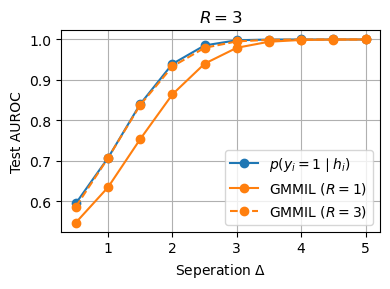

In [11]:
bayes_aurocs = [0.532806396484375, 0.5742870569229126, 0.6292170882225037, 0.7048004269599915, 0.7931671142578125, 0.8750880360603333, 0.9311984777450562, 0.9653711915016174, 0.9851321578025818, 0.9943505525588989]
bayes_aurocs = [0.5946202278137207, 0.7070890069007874, 0.8402831554412842, 0.9396085739135742, 0.9853242635726929, 0.9980275630950928, 0.9998959302902222, 0.9999998807907104, 0.9999999403953552, 0.9999999403953552]

ncols, nrows = 1, 1

fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows)

ax.plot(Deltas, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
ax.plot(Deltas, gmm_k1_aurocs, color="#FF7F0E", label=r"GMMIL ($R=1$)", marker="o")
ax.plot(Deltas, gmm_k3_aurocs, color="#FF7F0E", label=r"GMMIL ($R=3$)", linestyle="--", marker="o")

ax.set_title(r"$R=3$")
ax.set_xlabel(r"Seperation $\Delta$")
ax.set_ylabel("Test AUROC")
ax.legend()
ax.grid()

fig.tight_layout()
fig.savefig("gmmil.pdf", bbox_inches="tight")
plt.show()

In [14]:
utils.normal_pdf(h_i[:,0], 1.0, 1.0)

tensor([3.9574e-01, 3.9103e-01, 3.9653e-01, 1.2769e-02, 1.7648e-01, 2.8235e-01,
        2.2901e-01, 3.9664e-01, 2.7525e-02, 3.7059e-01, 2.4098e-01, 1.4726e-02,
        1.8364e-01, 3.8710e-01, 6.8426e-02, 9.2068e-02, 3.9054e-01, 2.9986e-01,
        9.6981e-02, 3.7038e-01, 1.1576e-01, 1.1890e-01, 3.4451e-01, 3.3443e-02,
        3.9614e-04, 3.1792e-01, 3.5944e-01, 2.7945e-01, 3.3784e-01, 1.7777e-01,
        3.9562e-01, 2.9485e-01, 2.1450e-01])

In [ ]:
auroc = torchmetrics.AUROC(task="binary")

Deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
bayes_aurocs = []

for Delta in Deltas:

    test_dataset = datasets.ShiftedMeanMILDataset(N=100, R=3, Delta=Delta, seed=2)
    
    bayes_probs = torch.stack([test_dataset[i] for i in range(len(test_dataset))])
    bayes_aurocs.append(auroc(bayes_probs, test_dataset.y).item())
    
print(bayes_aurocs)

In [4]:
def max_logits(X, lengths, delta):
    
    model = models.ClfPool(in_features=768, out_features=1, instance_conv=False, pooling="max", use_pos_embedding=False)

    state_dict = {
        "clf.weight": torch.zeros(1, 768),
        "clf.bias": torch.zeros(1),
    }

    state_dict["clf.weight"][0,0] = 1.0
    state_dict["clf.bias"][0] = -delta/2

    model.load_state_dict(state_dict)
    
    logits, attention_weights = model(X, lengths)
    
    return logits

def mean_logits(X, lengths, delta):
    
    model = models.ClfPool(in_features=768, out_features=1, instance_conv=False, pooling="mean", use_pos_embedding=False)

    state_dict = {
        "clf.weight": torch.zeros(1, 768),
        "clf.bias": torch.zeros(1),
    }

    state_dict["clf.weight"][0,0] = 1.0
    state_dict["clf.bias"][0] = -delta/2

    model.load_state_dict(state_dict)
    
    logits, attention_weights = model(X, lengths)
    
    return logits

def attention_logits(X, lengths, delta):
    
    model = models.ClfPool(in_features=768, out_features=1, instance_conv=False, pooling="attention", use_pos_embedding=False)
    
    state_dict = {
        "clf.weight": torch.zeros(1, 768),
        "clf.bias": torch.zeros(1),
        "pool.mlp.0.weight": torch.zeros(128, 1),
        "pool.mlp.0.bias": torch.zeros(128),
        "pool.mlp.2.weight": torch.zeros(1, 128),
        "pool.mlp.2.bias": torch.zeros(1),
    }

    state_dict["clf.weight"][0,0] = 1.0
    state_dict["clf.bias"][0] = -delta/2
    state_dict["pool.mlp.0.weight"][0,0] = 0.01
    state_dict["pool.mlp.2.weight"][0,0] = 100.0

    model.load_state_dict(state_dict)

    logits, attention_weights = model(X, lengths)
    
    return logits

In [5]:
auroc = torchmetrics.AUROC(task="binary")

Rs = [1, 3, 5]
Deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
bayes_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))
max_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))
mean_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))
attention_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))

with torch.no_grad():
    
    for i, R in enumerate(Rs):
            
        for j, Delta in enumerate(Deltas):
        
            train_dataset = datasets.ShiftedMeanMILDataset(N=400, R=R, Delta=Delta, seed=0)
            val_dataset = datasets.ShiftedMeanMILDataset(N=100, R=R, Delta=Delta, seed=1)
            test_dataset = datasets.ShiftedMeanMILDataset(N=1000, R=R, Delta=Delta, seed=2)
                
            # Bayes estimator
            bayes_probs = torch.stack([test_dataset.p_y1_given_h(i) for i in range(len(test_dataset))])
            bayes_aurocs[i,j] = auroc(bayes_probs, test_dataset.y).item()
        
            # Max pooling
            logits = max_logits(test_dataset.H, test_dataset.lengths, Delta)
            max_aurocs[i,j] = auroc(logits, test_dataset.y).item()
            
            # Mean pooling
            logits = mean_logits(test_dataset.H, test_dataset.lengths, Delta)
            mean_aurocs[i,j] = auroc(logits, test_dataset.y).item()
            
            # Attention-based pooling
            logits = attention_logits(test_dataset.H, test_dataset.lengths, Delta)
            attention_aurocs[i,j] = auroc(logits, test_dataset.y).item()


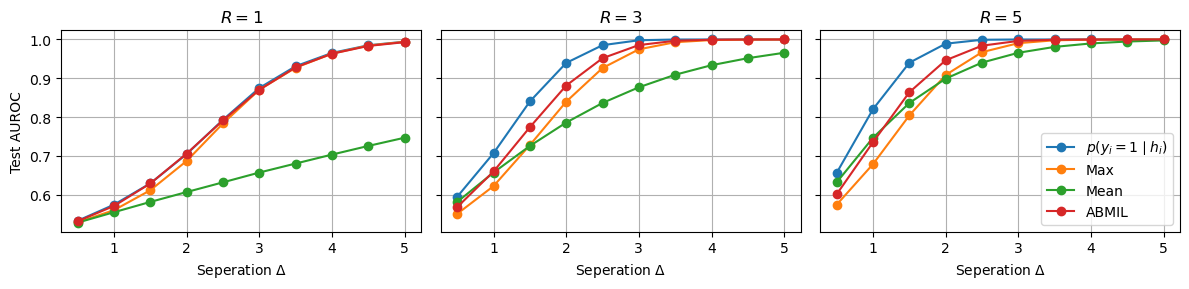

In [6]:
ncols, nrows = 3, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

for i, R in enumerate(Rs):

    axs[i].plot(Deltas, bayes_aurocs[i], color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
    axs[i].plot(Deltas, max_aurocs[i], color="#FF7F0E", label="Max", marker="o")
    axs[i].plot(Deltas, mean_aurocs[i], color="#2CA02C", label="Mean", marker="o")
    axs[i].plot(Deltas, attention_aurocs[i], color="#D62728", label="ABMIL", marker="o")
    axs[i].set_xlabel(r"Seperation $\Delta$")
    axs[i].set_title(rf"$R={R}$")
    axs[i].grid()
    
axs[0].set_ylabel("Test AUROC")
axs[2].legend(loc="lower right")

fig.tight_layout()
fig.savefig("handcrafted_parameters1.pdf", bbox_inches="tight")
plt.show()

In [7]:
def instance_logits(X, lengths, delta, kernel_size):
    
    model = models.ClfPool(in_features=768, out_features=1, instance_conv=True, kernel_size=kernel_size, pooling="attention", use_pos_embedding=False)
        
    state_dict = {
        "clf.weight": torch.zeros(1, 768),
        "clf.bias": torch.zeros(1),
        "conv.conv.weight": torch.zeros(1, 1, kernel_size),
        "conv.conv.bias": torch.zeros(1),
        "pool.mlp.0.weight": torch.zeros(128, 1),
        "pool.mlp.0.bias": torch.zeros(128),
        "pool.mlp.2.weight": torch.zeros(1, 128),
        "pool.mlp.2.bias": torch.zeros(1),
    }    
    
    state_dict["clf.weight"][0,0] = 1.0
    state_dict["clf.bias"][0] = -delta/2
    state_dict["conv.conv.weight"][0,0,:] = 1.0
    state_dict["pool.mlp.0.weight"][0,0] = 0.01
    state_dict["pool.mlp.2.weight"][0,0] = 100.0

    model.load_state_dict(state_dict)
    
    logits, attention_weights = model(X, lengths)
    
    return logits

In [11]:
auroc = torchmetrics.AUROC(task="binary")

Rs = [1, 3, 5]
Deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
bayes_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))
attention_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))
instance_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))

with torch.no_grad():
    
    for i, R in enumerate(Rs):
            
        for j, Delta in enumerate(Deltas):
        
            train_dataset = datasets.ShiftedMeanMILDataset(N=400, R=R, Delta=Delta, seed=0)
            val_dataset = datasets.ShiftedMeanMILDataset(N=100, R=R, Delta=Delta, seed=1)
            test_dataset = datasets.ShiftedMeanMILDataset(N=1000, R=R, Delta=Delta, seed=2)
                
            # Bayes estimator
            bayes_probs = torch.stack([test_dataset.p_y1_given_h(i) for i in range(len(test_dataset))])
            bayes_aurocs[i,j] = auroc(bayes_probs, test_dataset.y).item()
                
            # Attention-based pooling
            logits = attention_logits(test_dataset.H, test_dataset.lengths, Delta)
            attention_aurocs[i,j] = auroc(logits, test_dataset.y).item()
            
            # Attention-based pooling
            logits = instance_logits(test_dataset.H, test_dataset.lengths, Delta, R)
            instance_aurocs[i,j] = auroc(logits, test_dataset.y).item()


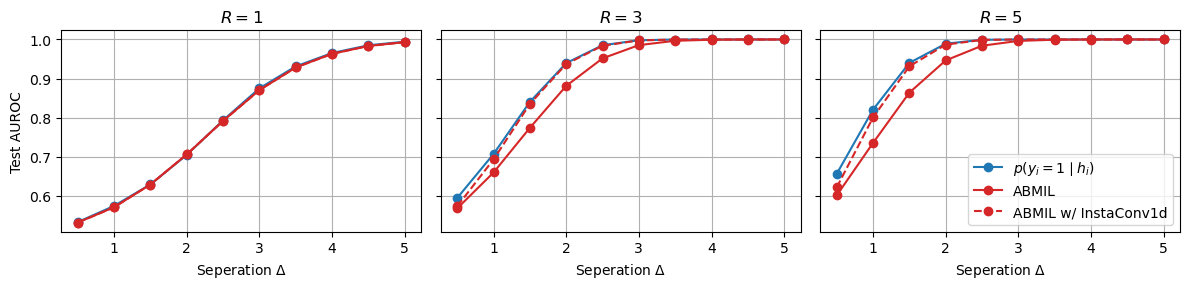

In [13]:
ncols, nrows = 3, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

for i, R in enumerate(Rs):

    axs[i].plot(Deltas, bayes_aurocs[i], color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
    axs[i].plot(Deltas, attention_aurocs[i], color="#D62728", label="ABMIL", marker="o")
    axs[i].plot(Deltas, instance_aurocs[i], color="#D62728", label="ABMIL w/ InstaConv1d", linestyle='--', marker="o")
    axs[i].set_xlabel(r"Seperation $\Delta$")
    axs[i].set_title(rf"$R={R}$")
    axs[i].grid()
    
axs[0].set_ylabel("Test AUROC")
axs[2].legend(loc="lower right")

fig.tight_layout()
fig.savefig("handcrafted_parameters2.pdf", bbox_inches="tight")
plt.show()


In [14]:
def transformer_logits(X, lengths, delta, seperation):
    
    embed_dim = 768
    model = models.PoolClf(in_features=embed_dim, out_features=1, pooling="transformer", use_pos_embedding=False)
    
    state_dict = {
        "pool.cls_token": torch.zeros(1, embed_dim),
        "pool.layer1.norm.weight": torch.zeros(embed_dim),
        "pool.layer1.norm.bias": torch.zeros(embed_dim),
        "pool.layer1.attn.in_proj_weight": torch.zeros(3 * embed_dim, embed_dim),
        "pool.layer1.attn.in_proj_bias": torch.zeros(3 * embed_dim),
        "pool.layer1.attn.out_proj.weight": torch.zeros(embed_dim, embed_dim),
        "pool.layer1.attn.out_proj.bias": torch.zeros(embed_dim),
        "pool.position_layer.proj1.weight": torch.zeros(embed_dim, 1, 3),
        "pool.position_layer.proj1.bias": torch.zeros(embed_dim),
        "pool.position_layer.proj2.weight": torch.zeros(embed_dim, 1, 5),
        "pool.position_layer.proj2.bias": torch.zeros(embed_dim),
        "pool.position_layer.proj3.weight": torch.zeros(embed_dim, 1, 7),
        "pool.position_layer.proj3.bias": torch.zeros(embed_dim),
        "pool.layer2.norm.weight": torch.zeros(embed_dim),
        "pool.layer2.norm.bias": torch.zeros(embed_dim),
        "pool.layer2.attn.in_proj_weight": torch.zeros(3 * embed_dim, embed_dim),
        "pool.layer2.attn.in_proj_bias": torch.zeros(3 * embed_dim),
        "pool.layer2.attn.out_proj.weight": torch.zeros(embed_dim, embed_dim),
        "pool.layer2.attn.out_proj.bias": torch.zeros(embed_dim),
        "clf.weight": torch.zeros(1, embed_dim),
        "clf.bias": torch.zeros(1),
    }
    
    eye = torch.eye(embed_dim)
    state_dict["pool.cls_token"][0,0] = -100.0
    if seperation == 1:
        state_dict["pool.position_layer.proj1.bias"][0] = torch.tensor([1*(-delta/2)])
    elif seperation == 3:
        state_dict["pool.position_layer.proj1.weight"][0,0,:] = torch.tensor([1.0, 0.0, 1.0])
        state_dict["pool.position_layer.proj1.bias"][0] = torch.tensor([3*(-delta/2)])
    elif seperation == 5:
        state_dict["pool.position_layer.proj2.weight"][0,0,:] = torch.tensor([1.0, 1.0, 0.0, 1.0, 1.0])
        state_dict["pool.position_layer.proj2.bias"][0] = torch.tensor([5*(-delta/2)])
    state_dict["pool.layer2.norm.weight"][0] = 1.0
    state_dict["pool.layer2.attn.in_proj_weight"] = torch.cat((-0.01*math.sqrt(embed_dim)*eye, eye, eye))
    state_dict["pool.layer2.attn.out_proj.weight"] = eye
    #matrix = torch.zeros(embed_dim, embed_dim)
    #matrix[:,0] = 1.0
    #linspace = torch.linspace(start=0.0, end=seperation, steps=768)
    #state_dict["pool.layer2.attn.in_proj_weight"] = torch.cat((-0.01*math.sqrt(embed_dim)*matrix, matrix, matrix))
    #state_dict["pool.layer2.attn.in_proj_bias"] = torch.cat((-linspace, -linspace, -linspace))
    #state_dict["pool.layer2.attn.out_proj.weight"] = (1/768**2)*torch.ones(embed_dim, embed_dim)
    state_dict["pool.layer2.attn.out_proj.bias"][0] = 100.0
    state_dict["clf.weight"][0,:] = 1.0
    state_dict["clf.bias"][0] = -delta/2
    
    model.load_state_dict(state_dict)
    
    logits, attention_weights = model(X, lengths)
    
    return logits

In [16]:
auroc = torchmetrics.AUROC(task="binary")

Rs = [1, 3, 5]
Deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
bayes_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))
transformer_aurocs = torch.zeros(size=(len(Rs), len(Deltas)))

with torch.no_grad():
    
    for i, R in enumerate(Rs):
            
        for j, Delta in enumerate(Deltas):
        
            train_dataset = datasets.ShiftedMeanMILDataset(N=400, R=R, Delta=Delta, seed=0)
            val_dataset = datasets.ShiftedMeanMILDataset(N=100, R=R, Delta=Delta, seed=1)
            test_dataset = datasets.ShiftedMeanMILDataset(N=1000, R=R, Delta=Delta, seed=2)
                
            # Bayes estimator
            bayes_probs = torch.stack([test_dataset.p_y1_given_h(i) for i in range(len(test_dataset))])
            bayes_aurocs[i,j] = auroc(bayes_probs, test_dataset.y).item()
                
            # TransMIL
            logits = transformer_logits(test_dataset.H, test_dataset.lengths, Delta, R)
            transformer_aurocs[i,j] = auroc(logits, test_dataset.y).item()


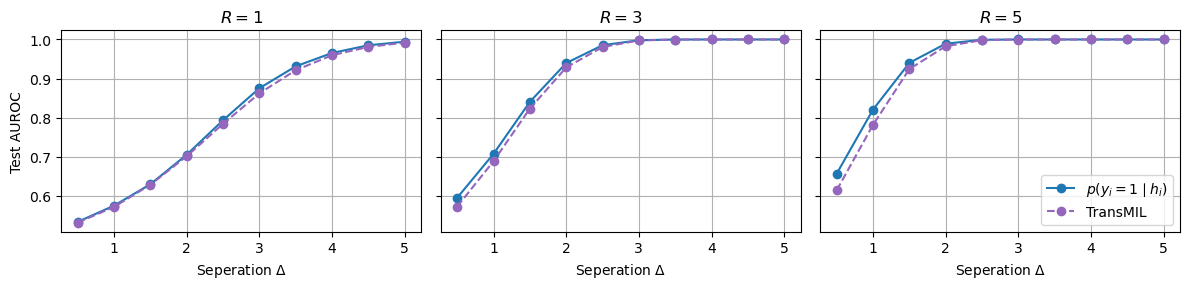

In [17]:
ncols, nrows = 3, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

for i, R in enumerate(Rs):

    axs[i].plot(Deltas, bayes_aurocs[i], color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
    axs[i].plot(Deltas, transformer_aurocs[i], color="#9467BD", label="TransMIL", linestyle='--', marker="o")
    axs[i].set_xlabel(r"Seperation $\Delta$")
    axs[i].set_title(rf"$R={R}$")
    axs[i].grid()
    
axs[0].set_ylabel("Test AUROC")
axs[2].legend(loc="lower right")

fig.tight_layout()
fig.savefig("handcrafted_parameters3.pdf", bbox_inches="tight")
plt.show()
